In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lsind18_gemstones_images_path = kagglehub.dataset_download('lsind18/gemstones-images')
print(lsind18_gemstones_images_path)
print('Data source import complete.')


100%|██████████| 55.2M/55.2M [00:03<00:00, 16.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/lsind18/gemstones-images/versions/6
Data source import complete.


# Import libraries, load and transform data

In [ ]:
!pip install -U transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 34.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.52.2
    Uninstalling transformers-4.52.2:
      Successfully uninstalled transformers-4.52.2


In [ ]:
!pip install -q evaluate transformers datasets mlflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.9/722.9 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.

In [ ]:
# imports
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import pandas as pd
import itertools
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score,
                             roc_auc_score,
                             confusion_matrix,
                             classification_report,
                             f1_score)

import evaluate
from datasets import Dataset, Image
from transformers import (TrainingArguments,
                          Trainer,
                          ViTImageProcessor,
                          ViTForImageClassification,
                          DefaultDataCollator)
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import (CenterCrop,
                                    Compose,
                                    Normalize,
                                    RandomRotation,
                                    RandomResizedCrop,
                                    RandomHorizontalFlip,
                                    RandomAdjustSharpness,
                                    Resize,
                                    ToTensor)

True
3219 3219
Dataset({
    features: ['image', 'label'],
    num_rows: 3219
})


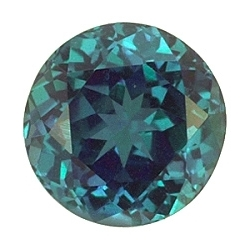

In [ ]:
# use https://huggingface.co/docs/datasets/image_load for reference

image_dict = {}
# Define the list of file names
from pathlib import Path
from tqdm import tqdm
file_names = []
labels = []
print(Path('/kaggle/input/gemstones-images/').exists())
for file in sorted((Path('/kaggle/input/gemstones-images/').glob('*/*/*.jpg'))):
    file_names.append(str(file))
    label = str(file).split('/')[-2]
    labels.append(label)
print(len(file_names), len(labels))

dataset = Dataset.from_dict({"image": file_names, "label": labels}).cast_column("image", Image())
print(dataset)
dataset[0]["image"]

In [ ]:
labels[:5]

['Alexandrite', 'Alexandrite', 'Alexandrite', 'Alexandrite', 'Almandine']

In [ ]:
labels_list = list(set(labels))
label2id, id2label = dict(), dict()
for i, label in enumerate(labels_list):
    label2id[label] = i
    id2label[i] = label

print(id2label, '\n\n', label2id)

{0: 'Onyx Red', 1: 'Garnet Red', 2: 'Chrysocolla', 3: 'Pyrope', 4: 'Cats Eye', 5: 'Kunzite', 6: 'Danburite', 7: 'Diamond', 8: 'Onyx Green', 9: 'Rhodochrosite', 10: 'Dumortierite', 11: 'Citrine', 12: 'Tsavorite', 13: 'Aquamarine', 14: 'Rhodonite', 15: 'Spodumene', 16: 'Aventurine Green', 17: 'Andradite', 18: 'Sphene', 19: 'Sapphire Pink', 20: 'Aventurine Yellow', 21: 'Tourmaline', 22: 'Sunstone', 23: 'Iolite', 24: 'Opal', 25: 'Amber', 26: 'Zoisite', 27: 'Prehnite', 28: 'Amethyst', 29: 'Coral', 30: 'Zircon', 31: 'Sapphire Yellow', 32: 'Quartz Rose', 33: 'Scapolite', 34: 'Pearl', 35: 'Chrysoprase', 36: 'Ametrine', 37: 'Spessartite', 38: 'Hessonite', 39: 'Sodalite', 40: 'Sapphire Blue', 41: 'Turquoise', 42: 'Quartz Beer', 43: 'Bloodstone', 44: 'Variscite', 45: 'Quartz Lemon', 46: 'Serpentine', 47: 'Labradorite', 48: 'Chrysoberyl', 49: 'Alexandrite', 50: 'Tanzanite', 51: 'Diaspore', 52: 'Larimar', 53: 'Quartz Rutilated', 54: 'Carnelian', 55: 'Sapphire Purple', 56: 'Hiddenite', 57: 'Onyx Bla

In [ ]:
dataset

Dataset({
    features: ['image', 'label'],
    num_rows: 3219
})

In [ ]:
dataset = dataset.train_test_split(test_size=0.2)
train_data = dataset['train']
test_data = dataset['test']

In [ ]:
del dataset
gc.collect()

186

In [ ]:
model_str = 'google/vit-base-patch16-224-in21k'
processor = ViTImageProcessor.from_pretrained(model_str)
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"]
print("Size: ", size)

normalize = Normalize(mean=image_mean, std=image_std)
_train_transforms = Compose(
        [
            Resize((size, size)),
            RandomRotation(15),
            RandomAdjustSharpness(2),
            ToTensor(),
            normalize,
        ]
    )

_val_transforms = Compose(
        [
            Resize((size, size)),
            ToTensor(),
            normalize,
        ]
    )

def train_transforms(examples):
    examples['pixel_values'] = [_train_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

def val_transforms(examples):
    examples['pixel_values'] = [_val_transforms(image.convert("RGB")) for image in examples['image']]
    return examples

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Size:  224


In [ ]:
# Set the transforms
train_data.set_transform(train_transforms)
test_data.set_transform(val_transforms)

In [ ]:
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([label2id[example["label"]] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

# Load, train, and evaluate model

In [ ]:
model = ViTForImageClassification.from_pretrained(model_str, num_labels=len(labels_list))
model.config.id2label = id2label
model.config.label2id = label2id
# number of trainable parameters
print(model.num_parameters(only_trainable=True)/1e6)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


85.865559


In [ ]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = eval_pred.predictions
    # predictions = np.exp(predictions)/np.exp(predictions).sum(axis=1, keepdims=True)
    label_ids = eval_pred.label_ids
    # Calculate accuracy using the loaded accuracy metric
    acc_score = accuracy.compute(predictions=predictions.argmax(axis=1), references=label_ids)['accuracy']


    return {
        "accuracy": acc_score
    }

In [ ]:
metric_name = "accuracy"
model_name = "gemstones_image_detection"
num_train_epochs=60
args = TrainingArguments(
    output_dir=model_name,
    logging_dir='./logs',
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=8,
    num_train_epochs=num_train_epochs,
    weight_decay=0.02,
    warmup_steps=50,
    remove_unused_columns=False,
    save_strategy='epoch',
    load_best_model_at_end=True,
    save_total_limit=1, # save fewer checkpoints to limit used space
    report_to="mlflow",  # log to mlflow
)

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_data,
    eval_dataset=test_data,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    tokenizer=processor,
)

In [ ]:
trainer.evaluate()

{'eval_loss': 4.468175411224365,
 'eval_model_preparation_time': 0.0028,
 'eval_accuracy': 0.007763975155279503,
 'eval_runtime': 10.63,
 'eval_samples_per_second': 60.583,
 'eval_steps_per_second': 7.62}

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy
1,No log,4.399428,0.002800,0.041925
2,No log,4.286202,0.002800,0.234472
3,No log,4.160917,0.002800,0.385093
4,No log,4.029165,0.002800,0.493789
5,No log,3.894427,0.002800,0.565217
6,No log,3.762676,0.002800,0.611801
7,4.032100,3.639564,0.002800,0.650621
8,4.032100,3.525830,0.002800,0.673913
9,4.032100,3.424152,0.002800,0.692547
10,4.032100,3.321991,0.002800,0.697205


Epoch,Training Loss,Validation Loss,Model Preparation Time,Accuracy
1,No log,4.399428,0.002800,0.041925
2,No log,4.286202,0.002800,0.234472
3,No log,4.160917,0.002800,0.385093
4,No log,4.029165,0.002800,0.493789
5,No log,3.894427,0.002800,0.565217
6,No log,3.762676,0.002800,0.611801
7,4.032100,3.639564,0.002800,0.650621
8,4.032100,3.525830,0.002800,0.673913
9,4.032100,3.424152,0.002800,0.692547
10,4.032100,3.321991,0.002800,0.697205


TrainOutput(global_step=4860, training_loss=1.9997680224508905, metrics={'train_runtime': 8314.2938, 'train_samples_per_second': 18.582, 'train_steps_per_second': 0.585, 'total_flos': 1.1981633391995904e+19, 'train_loss': 1.9997680224508905, 'epoch': 60.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 1.6686522960662842,
 'eval_model_preparation_time': 0.0028,
 'eval_accuracy': 0.8307453416149069,
 'eval_runtime': 8.537,
 'eval_samples_per_second': 75.437,
 'eval_steps_per_second': 9.488,
 'epoch': 60.0}

In [ ]:
outputs = trainer.predict(test_data)
print(outputs.metrics)

In [ ]:
y_true = outputs.label_ids
y_pred = outputs.predictions.argmax(1)

# plotting confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    This function plots a confusion matrix.

    Parameters:
        cm (array-like): Confusion matrix as returned by sklearn.metrics.confusion_matrix.
        classes (list): List of class names, e.g., ['Class 0', 'Class 1'].
        title (str): Title for the plot.
        cmap (matplotlib colormap): Colormap for the plot.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.0f'
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    plt.tight_layout()
    plt.show()

# Calculate accuracy and F1 score
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

# Display accuracy and F1 score
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

# Get the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plot_confusion_matrix(cm, labels_list)

In [ ]:
trainer.save_model()

In [ ]:
from transformers import pipeline

pipe = pipeline('image-classification',model=model_name,device=0)

In [ ]:
image = test_data[1]["image"]

image

In [ ]:
pipe(image)

In [ ]:
# actual label
test_data[1]["label"]

# Send model to Huggingface

In [ ]:
# finally, save the model to Huggingface
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import HfApi
api = HfApi()
repo_id = f"dima806/{model_name}"
try:
    api.create_repo(repo_id)
    print(f"Repo {repo_id} created")
except:
    print(f"Repo {repo_id} already exists")

In [ ]:
api.upload_folder(
    folder_path=model_name,
    path_in_repo = ".",
    repo_id=repo_id,
    repo_type="model"
)